## 99. Debugging

### 0. Packages

In [ ]:
# Packages
import datetime
#import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray as rxr
import xarray as xr
import glob
import contextily as ctx

### 1. Load the data

In [ ]:
# File paths
file_path_tiles = r'p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v2.parquet'
file_path_gtsm_stations= r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_filtered_v2.parquet'
file_path_mask = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_mask_ed = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'
file_path_gtsm_combined = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'

In [ ]:
# Read data
gdf_tiles = gpd.read_parquet(file_path_tiles)
gdf_stations = gpd.read_parquet(file_path_gtsm_stations)
gdf_mask = gpd.read_parquet(file_path_mask)
gdf_mask_ed = gpd.read_parquet(file_path_mask_ed)
ds_gtsm = xr.open_zarr(file_path_gtsm_combined)

# Convert station name to string
gdf_stations['station_name'] = gdf_stations['station_name'].astype(str)

# Make station id the index of stations
ds_gtsm = ds_gtsm.set_index(stations='station_id')

### 2. Checking tiles

In [ ]:
# File path bathy
file_path_bathy = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_upscaled_v3\03_merged\z10_x507_y363_t2021-01-01_2022-01-01_100m.tif'

# Open bathy
da_bathy = rxr.open_rasterio(file_path_bathy)

In [ ]:
# Get tile
gdf_tile = gdf_tiles[gdf_tiles['name'] == 'z10_x507_y363']
gdf_tile.head()

In [ ]:
# Get station
gdf_station = gdf_stations[gdf_stations['station_id'] == gdf_tile['nearest_station_id'].values[0]]
gdf_station.head()

In [ ]:
# Plot tile and station
m = folium.Map(location=[gdf_station.geometry.y.iloc[0], gdf_station.geometry.x.iloc[0]], zoom_start=10)
m = gdf_tile.explore(m=m, color='red')
m = gdf_station.explore(m=m, color='blue')
m

In [ ]:
# Get GTSM data for station and period
period = slice('2021-03-22', '2021-03-30')
ds_gtsm_ss = ds_gtsm.sel(stations=gdf_station['station_id'].values[0]).sel(time=period)
print('Station id:', gdf_station['station_id'].values[0])

# Get times and waterlevels from bathymetry
times = eval(da_bathy.attrs['gtsm_times'])
waterlevels = eval(da_bathy.attrs['gtsm_water_levels'])
print('Station id:', da_bathy.attrs['gtsm_station'])

# Plot timeseries
fig, ax = plt.subplots(figsize=(15, 5))
ds_gtsm_ss['waterlevel'].plot(ax=ax)
ax.scatter(times, waterlevels, color='red', s=2, zorder=2)
ax.hlines(y=gdf_station['lat'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='red')
ax.hlines(y=gdf_station['hat'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='green')

#ax.hlines(y=gdf_station['bedlevel'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='red')
ax.set_xlim(ds_gtsm_ss['time'].min(), ds_gtsm_ss['time'].max())

### Checking stations

In [ ]:
# Get GTSM data for station and period
station_id = 'station 03721'
period = slice('2020-10-01', '2020-11-01')
gdf_station = gdf_stations[gdf_stations['station_id'] == station_id]
ds_gtsm_ss = ds_gtsm.sel(stations=station_id).sel(time=period)

# Plot timeseries
fig, ax = plt.subplots(figsize=(15, 5))
ds_gtsm_ss['waterlevel'].plot(ax=ax)
ax.hlines(y=gdf_station['lat'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='red')
ax.hlines(y=gdf_station['hat'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='green')

### 2. Checking bathymetries

In [ ]:
from morphopy import DataArrayList
from morphopy.process import get_gradient
from tqdm import tqdm
import glob
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from resilientplotterclass import rpc

# Load bathymetries
file_path_bathys = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_upscaled_v4\03_merged\*.tif')
grids = DataArrayList()
for file_path_bathy in tqdm(file_path_bathys):
    grids.read(file_path_bathy, long_name = '_'.join(os.path.basename(file_path_bathy).split('_')[0:3]), unit='m')

# Load mask
file_path_mask = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_mask_ed = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'
gdf_mask = gpd.read_parquet(file_path_mask)
gdf_mask_ed = gpd.read_parquet(file_path_mask_ed)

In [ ]:
# Get gradient
grid = grids[0]
magnitude, _ = get_gradient(grid)
mask = magnitude.isel(band=0) > 85

fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs = axs.flatten()
rpc.imshow(grid.isel(band=0), ax=axs[0], data_type='bathymetry')
rpc.imshow(magnitude.isel(band=0), ax=axs[1], data_type='data', cmap='viridis')
rpc.imshow(grid.isel(band=0).where(mask), ax=axs[2], data_type='bathymetry')
rpc.basemap(ax=axs[2], crs=grid.crs, map_type='satellite')
axs[3].set_xlim(grid.x.min(), grid.x.max())
axs[3].set_ylim(grid.y.min(), grid.y.max())
rpc.basemap(ax=axs[3], crs=grid.crs, map_type='satellite')
gdf_mask.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='red', linewidth=1)
gdf_mask_ed.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='blue', linewidth=1)
fig.tight_layout()

In [ ]:
# Otsu thresholding 3 classes
from skimage.filters import threshold_multiotsu
import numpy as np
from morphopy.utils import createDataArray
grid = grids[5]
thresholds = threshold_multiotsu(grid.isel(band=0).values[~np.isnan(grid.isel(band=0).values)], classes=3)
classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=thresholds), x=grid.x, y=grid.y, crs=grid.crs)
mask = (classes > 0) & (classes < len(thresholds))
percentage = mask.sum() / mask.size
print('Percentage:', float(percentage))

# Optimise top threshold
percentage_new = percentage
while np.abs(percentage_new - percentage) < 0.10:
    thresholds[-1] += 0.05
    classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=thresholds), x=grid.x, y=grid.y, crs=grid.crs)
    mask = (classes > 0) & (classes < len(thresholds))
    percentage_new = mask.sum() / mask.size
    print('Percentage new:', float(percentage_new))
thresholds[-1] -= 0.05
classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=thresholds), x=grid.x, y=grid.y, crs=grid.crs)
mask = (classes > 0) & (classes < len(thresholds))
percentage = mask.sum() / mask.size
print('Percentage:', float(percentage))

import matplotlib as mpl
fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs = axs.flatten()
rpc.imshow(grid.isel(band=0), ax=axs[0], data_type='bathymetry')
cmap = mpl.colors.ListedColormap([mpl.colormaps['tab10'](i) for i in range(len(thresholds)+1)])
rpc.imshow(classes, ax=axs[1], data_type='data', cmap=cmap, vmin=-0.5, vmax=len(thresholds)+0.5)
rpc.imshow(grid.isel(band=0).where(mask), ax=axs[2], data_type='bathymetry')
rpc.basemap(ax=axs[2], crs=grid.crs, map_type='satellite')
axs[3].set_xlim(grid.x.min(), grid.x.max())
axs[3].set_ylim(grid.y.min(), grid.y.max())
rpc.basemap(ax=axs[3], crs=grid.crs, map_type='satellite')
gdf_mask.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='red', linewidth=1)
#gdf_mask_ed.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='blue', linewidth=1)
fig.tight_layout()

In [ ]:
# Histogram thresholding 2 thresholds
import numpy as np
from morphopy.utils import createDataArray
grid = [grid for grid in grids if grid.attrs['long_name'] == 'z10_x835_y585'][0]
range = (np.nanmin(grid.isel(band=0).values), np.nanmax(grid.isel(band=0).values))
bin_size = 0.01
bins = np.arange(range[0], range[1]+bin_size, bin_size)
counts, bins = np.histogram(grid.isel(band=0).values[~np.isnan(grid.isel(band=0).values)], bins=bins)

# Sort bins according to count
bins_sorted = bins[counts.argsort()]
count_sorted = counts[counts.argsort()]

# Get cutoffs
cutoffs = [0, 0]
cutoffs[0] = bins_sorted[bins_sorted < 0][-1] + bin_size/2
cutoffs[1] = bins_sorted[bins_sorted > 0][0] - bin_size/2

# Get mask
classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=cutoffs), x=grid.x, y=grid.y, crs=grid.crs)
mask = (grid.isel(band=0) > cutoffs[0]) & (grid.isel(band=0) < cutoffs[1])

fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs = axs.flatten()
rpc.imshow(grid.isel(band=0), ax=axs[0], data_type='bathymetry')
rpc.imshow(classes, ax=axs[1], data_type='data', cmap='Spectral_r', vmin=-0.5, vmax=len(cutoffs)+0.5)
rpc.imshow(grid.isel(band=0).where(mask), ax=axs[2], data_type='bathymetry')
rpc.basemap(ax=axs[2], crs=grid.crs, map_type='satellite')
axs[3].set_xlim(grid.x.min(), grid.x.max())
axs[3].set_ylim(grid.y.min(), grid.y.max())
rpc.basemap(ax=axs[3], crs=grid.crs, map_type='satellite')
gdf_mask.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='red', linewidth=1)
gdf_mask_ed.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='blue', linewidth=1)
fig.tight_layout()

In [ ]:
# File path bathy
file_path_bathys = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_upscaled_v3\03_merged\*.tif')
file_path_bathy = file_path_bathys[12] # 12

# Open bathy
da_bathy = rxr.open_rasterio(file_path_bathy)

# Get
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()
out = da_bathy.isel(band=0).plot.hist(bins=100, ax=axs[0])
count = out[0]
bins = out[1]

# Get binsize
binsize =  bins[1] - bins[0]

# Sort bins according to count
bins_sorted = bins[count.argsort()]
count_sorted = count[count.argsort()]

# Get largest bin below 0
bins_below_0 = bins_sorted[bins_sorted < 0]
cutoffs = [0, 0]
cutoffs[0] = bins_below_0[-1] + binsize

# Get largest bin above 0
bins_above_0 = bins_sorted[bins_sorted > 0]
cutoffs[1] = bins_above_0[0] - binsize

print(cutoffs)

da_bathy2 = da_bathy.where((da_bathy.isel(band=0) > cutoffs[0]) & (da_bathy.isel(band=0) < cutoffs[1]))
da_bathy2.isel(band=0).plot(ax=axs[1], cmap='Spectral_r')
da_bathy2.isel(band=1).plot(ax=axs[2])
ctx.add_basemap(ax=axs[1], crs=da_bathy2.rio.crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
ctx.add_basemap(ax=axs[2], crs=da_bathy2.rio.crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
fig.tight_layout()

In [ ]:
# Histogram thresholding 2 thresholds
import numpy as np
from morphopy.utils import createDataArray
grid = [grid for grid in grids if grid.attrs['long_name'] == 'z10_x835_y585'][0]




range = (np.nanmin(grid.isel(band=0).values), np.nanmax(grid.isel(band=0).values))
bin_size = 0.01
bins = np.arange(range[0], range[1]+bin_size, bin_size)
counts, bins = np.histogram(grid.isel(band=0).values[~np.isnan(grid.isel(band=0).values)], bins=bins)

# Sort bins according to count
bins_sorted = bins[counts.argsort()]
count_sorted = counts[counts.argsort()]

# Get cutoffs
cutoffs = [0, 0]
cutoffs[0] = bins_sorted[bins_sorted < 0][-1] + bin_size/2
cutoffs[1] = bins_sorted[bins_sorted > 0][0] - bin_size/2

# Get mask
classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=cutoffs), x=grid.x, y=grid.y, crs=grid.crs)
mask = (grid.isel(band=0) > cutoffs[0]) & (grid.isel(band=0) < cutoffs[1])

fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs = axs.flatten()
rpc.imshow(grid.isel(band=0), ax=axs[0], data_type='bathymetry')
rpc.imshow(classes, ax=axs[1], data_type='data', cmap='Spectral_r', vmin=-0.5, vmax=len(cutoffs)+0.5)
rpc.imshow(grid.isel(band=0).where(mask), ax=axs[2], data_type='bathymetry')
rpc.basemap(ax=axs[2], crs=grid.crs, map_type='satellite')
axs[3].set_xlim(grid.x.min(), grid.x.max())
axs[3].set_ylim(grid.y.min(), grid.y.max())
rpc.basemap(ax=axs[3], crs=grid.crs, map_type='satellite')
gdf_mask.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='red', linewidth=1)
gdf_mask_ed.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='blue', linewidth=1)
fig.tight_layout()

In [ ]:
import rioxarray as rxr

file_path_mask_nc = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\Input\Processed_gebco_2024\Land_water_mask\Land_water_mask\LandWater15ARC.nc'
file_path_mask_tif = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\Input\Processed_gebco_2024\Land_water_mask\Land_water_mask\LandWater15ARC.tif'

# Read mask
da_mask = rxr.open_rasterio(file_path_mask_nc)
da_mask = da_mask.rio.write_crs('epsg:4326')

# Clip mask to bounds
bounds = [-6.405029, 45.798170, 2.526855, 50.527397]
da_mask = da_mask.rio.clip_box(*bounds)

# Write mask
da_mask.rio.to_raster(file_path_mask_tif)

In [ ]:
url_tif = r'https://storage.googleapis.com/global-surface-water/downloads2021/occurrence/occurrence_10W_60Nv1_4_2021.tif'
file_path_tif = os.path.join(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_temp', os.path.basename(url_tif))

# Read mask
da_occurrence = rxr.open_rasterio(url_tif)

# Write mask
da_occurrence.rio.to_raster(file_path_tif)

In [ ]:
url_tif = r'https://storage.googleapis.com/global-surface-water/downloads2021/occurrence/occurrence_10W_50Nv1_4_2021.tif'
file_path_tif = os.path.join(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_temp', os.path.basename(url_tif))

# Read mask
da_occurrence = rxr.open_rasterio(url_tif)

# Write mask
da_occurrence.rio.to_raster(file_path_tif)

In [ ]:
file_path_sea = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\01_osm_files\water_polygons.parquet'
gdf_sea_all = gpd.read_parquet(file_path_sea)

In [ ]:
import osmnx as ox
from shapely.geometry import box
import geopandas as gpd

# Get bbox
grid = [grid for grid in grids if grid.attrs['long_name'] == 'z10_x506_y358'][0]
bounds = grid.rio.bounds()
bounds = [4, 51, 5, 52]

# Get sea polygons in bbox
#gdf_sea = gdf_sea_all.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

# Get water polygons
gdf_water = ox.features_from_bbox(bounds, tags={'natural': 'water'})
gdf_water = gdf_water[gdf_water.area > 0.0001]
gdf_water = gdf_water.to_crs(epsg=4326)

In [ ]:
gdf_sea.explore()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
#grid.isel(band=0).plot.imshow(ax=axs[0])
gdf_sea.plot(ax=axs[1], color='red', alpha=0.5)
#gdf_water.plot(ax=axs[1], color='blue', alpha=0.5)
for ax in axs:
    #ax.set_xlim(grid.x.min(), grid.x.max())
    #ax.set_ylim(grid.y.min(), grid.y.max())
    ax.set_aspect('equal')

### Clipping test

In [ ]:
import os
import glob
import rioxarray as rxr
import matplotlib.pyplot as plt
from skimage.morphology import binary_erosion, binary_dilation, disk, footprint_rectangle
import numpy as np

In [ ]:
# File paths
file_path_osm_water_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\water_rasters\n45w005.tif'
file_path_image_tifs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_upscaled_v4\04_reprojected\*.tif')
file_path_image_tifs = [file_path_image_tif for file_path_image_tif in file_path_image_tifs if os.path.basename(file_path_image_tif).split('_t')[0] in ['z10_x505_y358', 'z10_x506_y358', 'z10_x505_y359', 'z10_x506_y359']]
file_path_osm_water_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\01_osm_files\water_polygons.parquet'

# Read tifs
da_osm_water = rxr.open_rasterio(file_path_osm_water_tif).isel(band=0)
da_image_ls = [rxr.open_rasterio(file_path_image_tif).isel(band=0) for file_path_image_tif in file_path_image_tifs]
da_osm_water_ls = [da_osm_water.rio.reproject_match(da) for da in da_image_ls]

# Create water mask (0: no water, 1: water)
da_mask_ls = [(da == 1) | (da == 2) for da in da_osm_water_ls]

# Footprints
smooth_footprint = disk(5)
buffer_land_footprint = disk(10)
buffer_water_footprint = disk(50)
smooth_footprint2 = disk(1)

# Smooth mask
da_mask_smooth_ls = [da.copy() for da in da_mask_ls]
for i, da in enumerate(da_mask_smooth_ls):
    mask = binary_erosion(da.values, smooth_footprint)
    mask = binary_dilation(mask, smooth_footprint)
    da_mask_smooth_ls[i].values = mask

# Buffer mask
da_mask_buffer_ls = [da.copy() for da in da_mask_smooth_ls]
for i, da in enumerate(da_mask_buffer_ls):
    mask_land = binary_dilation(da.values, buffer_land_footprint)
    mask_water = binary_dilation(~da.values, buffer_water_footprint)
    mask = mask_land & mask_water
    da_mask_buffer_ls[i].values = mask

# Apply masks
da_image_masked_ls = [da.where(da_osm_mask) for da, da_osm_mask in zip(da_image_ls, da_mask_ls)]
da_image_smooth_masked_ls = [da.where(da_osm_mask) for da, da_osm_mask in zip(da_image_ls, da_mask_smooth_ls)]
da_image_buffer_masked_ls = [da.where(da_osm_mask) for da, da_osm_mask in zip(da_image_ls, da_mask_buffer_ls)]

# Histogram mask
da_mask_hist_ls = [da.copy() for da in da_image_buffer_masked_ls]
for i, da in enumerate(da_image_buffer_masked_ls):
    range = (np.nanmin(da.values), np.nanmax(da.values))
    bin_size = 0.01
    counts, bins = np.histogram(da.values[~np.isnan(da.values)], bins=np.arange(range[0], range[1]+bin_size, bin_size), density=True)
    bins_sorted = bins[counts.argsort()]
    count_sorted = counts[counts.argsort()]
    cutoffs = [-np.inf, np.inf]
    cutoffs[0] = bins_sorted[bins_sorted < 0][-1] + bin_size/2
    cutoffs[1] = bins_sorted[bins_sorted > 0][0] - bin_size/2
    cutoffs[0] = np.nanpercentile(da, 5)
    cutoffs[1] = np.nanpercentile(da, 95)
    print(cutoffs)
    da_mask_hist_ls[i].values = (da > cutoffs[0]) & (da < cutoffs[1])

# Smooth mask
da_mask_smooth2_ls = [da.copy() for da in da_mask_hist_ls]
for i, da in enumerate(da_mask_smooth2_ls):
    mask = binary_erosion(da.values, smooth_footprint2)
    mask = binary_dilation(mask, smooth_footprint2)
    da_mask_smooth2_ls[i].values = mask

# Apply masks
da_image_hist_masked_ls = [da.where(da_osm_mask) for da, da_osm_mask in zip(da_image_ls, da_mask_hist_ls)]
da_image_smooth2_masked_ls = [da.where(da_osm_mask) for da, da_osm_mask in zip(da_image_ls, da_mask_smooth2_ls)]

[np.float32(-2.5469203), np.float32(1.3740075)]
[np.float32(-3.1415908), np.float32(1.4024161)]
[np.float32(-0.2059121), np.float32(1.2247677)]
[np.float32(-3.0659974), np.float32(1.3922546)]


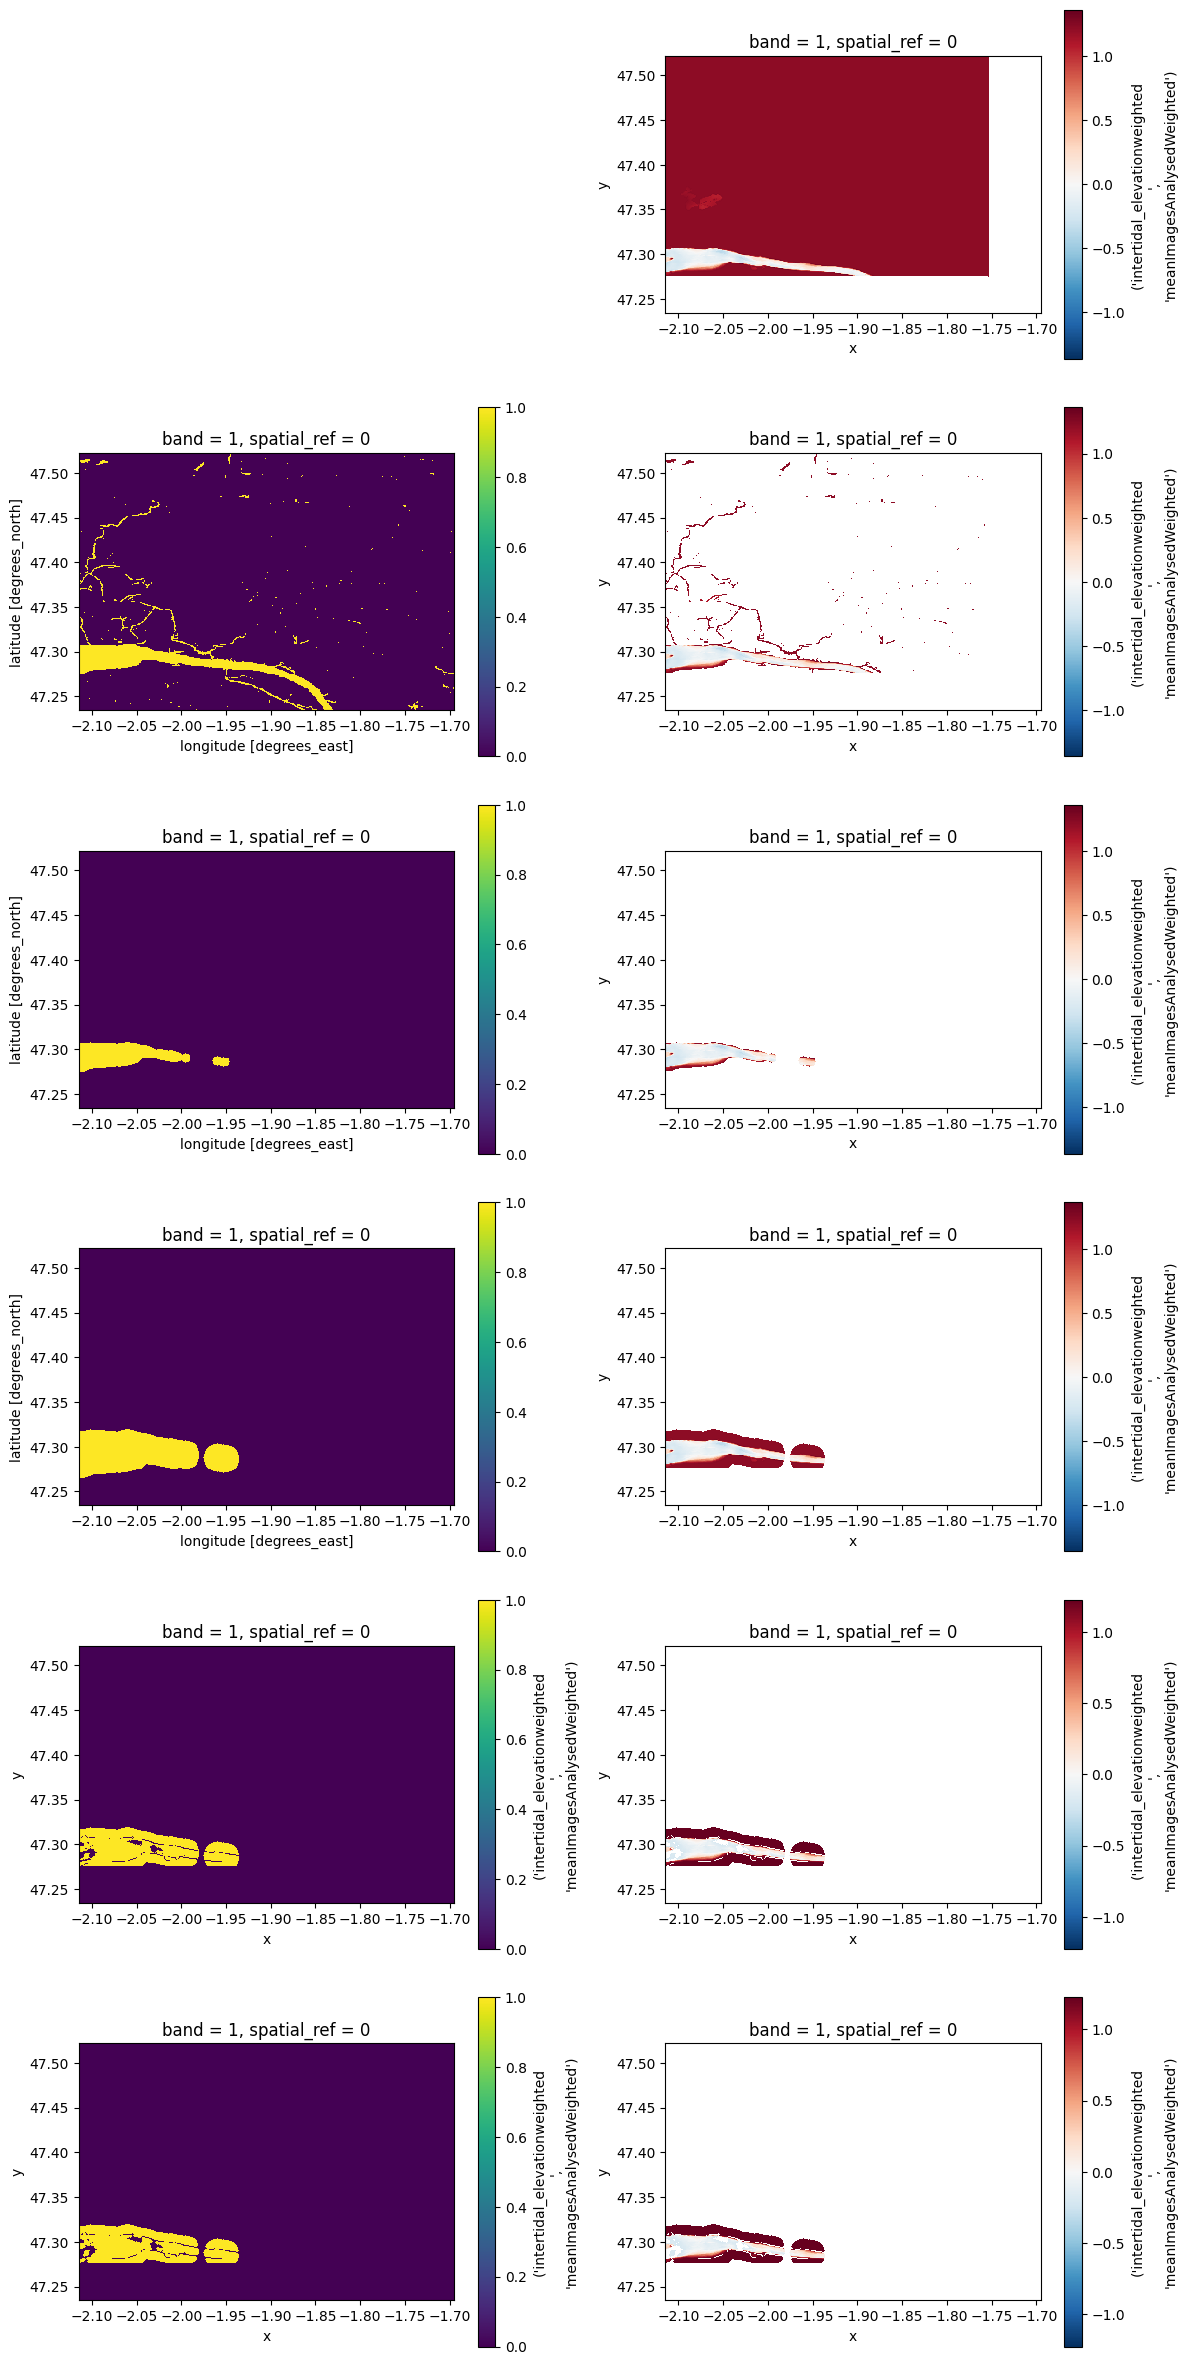

In [ ]:
i = 2
fig, axs = plt.subplots(6, 2, figsize=(12, 24))
axs = axs.flatten()
axs[0].axis('off')
da_image_ls[i].plot.imshow(ax=axs[1])
da_mask_ls[i].plot.imshow(ax=axs[2])
da_image_masked_ls[i].plot.imshow(ax=axs[3])
da_mask_smooth_ls[i].plot.imshow(ax=axs[4])
da_image_smooth_masked_ls[i].plot.imshow(ax=axs[5])
da_mask_buffer_ls[i].plot.imshow(ax=axs[6])
da_image_buffer_masked_ls[i].plot.imshow(ax=axs[7])
da_mask_hist_ls[i].plot.imshow(ax=axs[8])
da_image_hist_masked_ls[i].plot.imshow(ax=axs[9])
da_mask_smooth2_ls[i].plot.imshow(ax=axs[10])
da_image_smooth2_masked_ls[i].plot.imshow(ax=axs[11])

for ax in axs:
    ax.set_aspect('equal')
fig.tight_layout()

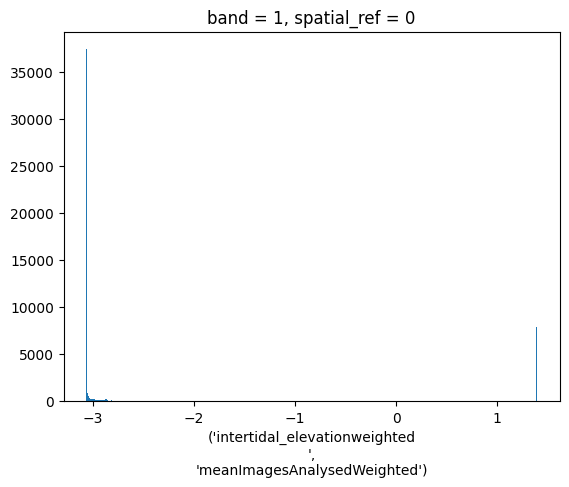

In [ ]:
i = 1
range = (np.nanmin(da_image_buffer_masked_ls[i].values), np.nanmax(da_image_buffer_masked_ls[i].values))
bin_size = 0.01
bins = da_image_buffer_masked_ls[i].plot.hist(bins=np.arange(range[0], range[1]+bin_size, bin_size))

### Test

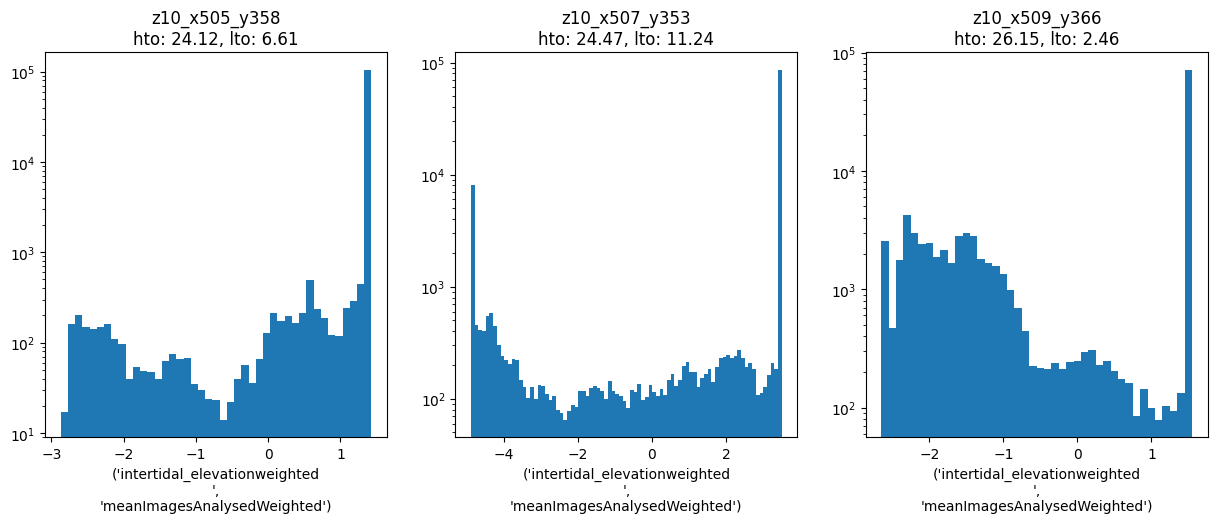

In [ ]:
file_path_image_tifs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_upscaled_v4\03_merged\*.tif')
ss = ['z10_x507_y353', 'z10_x509_y366', 'z10_x505_y358']
file_path_image_tifs = [file_path for file_path in file_path_image_tifs if os.path.basename(file_path).split('_t')[0] in ss]

# Load bathy
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()
for ax, file_path_image_tif in zip(axs, file_path_image_tifs):
    # Get data
    da = rxr.open_rasterio(file_path_image_tif).isel(band=0)

    # Get metadata
    metadata = {'name': os.path.basename(file_path_image_tif).split('_t')[0], 'hto': da.attrs['high_tide_offset'], 'lto': da.attrs['low_tide_offset']}
    
    range = (np.nanmin(da.values), np.nanmax(da.values))
    bin_size = 0.1
    bins = da.plot.hist(ax=ax, bins=np.arange(range[0], range[1]+bin_size, bin_size), yscale='log')
    ax.set_title('{}\nhto: {:.2f}, lto: {:.2f}'.format(metadata['name'], metadata['hto'], metadata['lto']))
    

### Check waterlevels

In [12]:
import datetime
import ee
import matplotlib.pyplot as plt

ee.Initialize()

In [13]:
# Settings
years = ['2019', '2020', '2021', '2022', '2023']
bounds = [6.91, 53.42, 6.93, 53.44]

# Get stations
gtsm_cols = [ee.FeatureCollection('projects/bathymetry/assets/gtsm_waterlevels_{}_v2'.format(year)) for year in years]
gtsm_cols = [gtsm_col.filterBounds(ee.Geometry.Rectangle(bounds)) for gtsm_col in gtsm_cols]
gtsm_lengths = [ee.FeatureCollection(gtsm_col).size() for gtsm_col in gtsm_cols]

# Get times
gtsm_times = [gtsm_col.aggregate_array('times').getInfo() for gtsm_col in gtsm_cols]
gtsm_times = [[datetime.datetime.strptime(gtsm_time[:-3], '%Y-%m-%dT%H:%M:%S.%f') for gtsm_time in gtsm_times[i]] for i in range(len(gtsm_times))]

# Get waterlevels
gtsm_waterlevels = [gtsm_col.aggregate_array('waterlevel').getInfo() for gtsm_col in gtsm_cols]

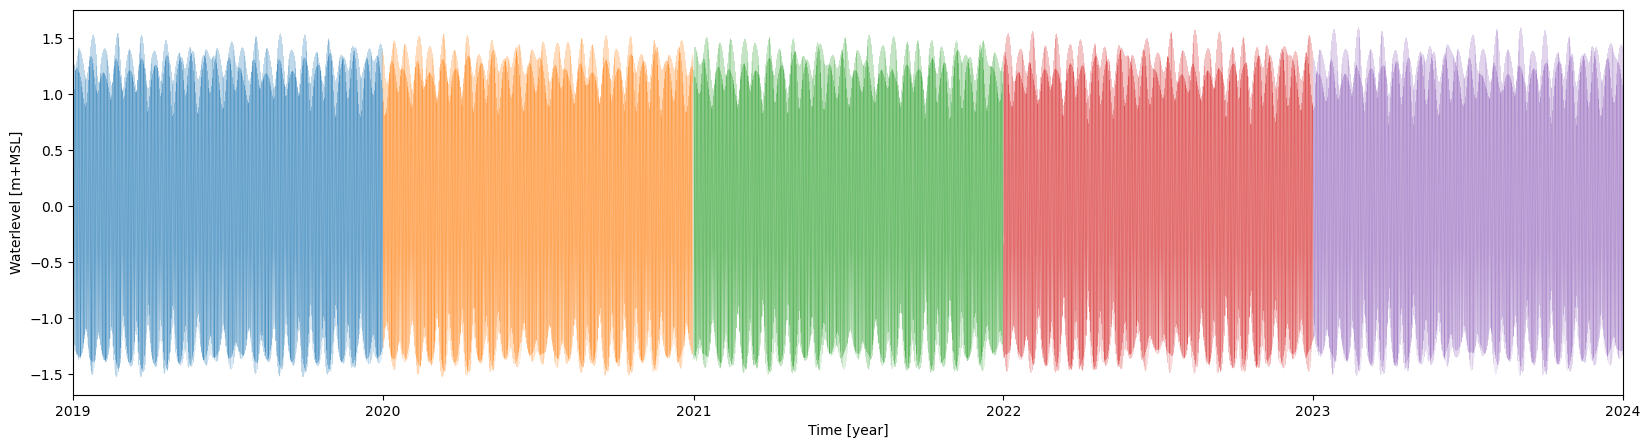

In [47]:
fig, ax = plt.subplots(figsize=(20, 5))
for gtsm_time, gtsm_waterlevel in zip(gtsm_times, gtsm_waterlevels):
    ax.plot(gtsm_time, gtsm_waterlevel, linewidth=0.1)
    ax.set_xlim([datetime.datetime(2019, 1, 1), datetime.datetime(2024, 1, 1)])
    ax.set_xlabel('Time [year]')
    ax.set_ylabel('Waterlevel [m+MSL]')